# Video Game Sales Analysis

Name: Khoa Le

Course: CMPS 6790

Deliverable 2

GitHub Repository: https://github.com/khoaboa1/khoaboa1.github.io

Dataset 1 — VGChartz Sales: https://www.kaggle.com/datasets/gregorut/videogamesales?resource=download

Dataset 2 — Metacritic Scores: https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings

Github Webpage: https://khoaboa1.github.io/

---

## Outline
1. [Project Goal & Plan](#1)
2. [ETL — Dataset 1: VGChartz Sales](#2)
3. [ETL — Dataset 2: Metacritic Scores](#3)
4. [ETL — Merged Dataset](#4)
5. [Exploratory Data Analysis (EDA)](#5)
6. [Hypothesis Testing](#6)
7. [Predictive Models](#7)
8. [Conclusion](#8)
9. [References](#9)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None, 'display.max_columns', None)
sns.set_theme(style='whitegrid')

In [22]:
df_vg = pd.read_csv('data/vgsales.csv')

print('Before cleaning:')
df_vg.info()
df_vg.isnull().sum()

Before cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

## Project Goal
For this project, I will be working individually to investigate patterns in the global video game industry using two datasets: the Video Game Sales dataset from VGChartz and Metacritic review scores. Together, these datasets cover over 16,000 games released between 1980 and 2020 and allow us to examine both commercial performance and critical reception.

I chose this topic because I enjoy video games and the industry represents one of the fastest-growing entertainment sectors of the past four decades. The data provides a rare opportunity to trace the development of the industry over time and across markets.

This project focuses on two questions, and both datasets are used to answer each of them:

Question 1 — Platform dominance over time: Which gaming platforms have dominated global sales, and how has that dominance shifted across decades?
- VGChartz provides the sales figures by platform and year — showing which platforms sold the most and when.
- Metacritic adds average critic scores by platform, helping explain why certain platforms dominated, not just that they did. Were the top-selling platforms also home to higher-quality, better-reviewed games?

Question 2 — What predicts a commercial hit? Can genre, platform, release year, and critical reception predict whether a game will sell over 1 million units?
- VGChartz provides the target variable (Global Sales) and core features: Genre, Platform, Year, and Publisher.
- Metacritic adds critical reception features: Critic Score, User Score, and ESRB Rating — capturing whether a game was well-received, which may independently predict commercial success beyond genre and platform alone.

## Project Plan
With the two questions above, both datasets are well-positioned to support this analysis. The VGChartz data provides regional sales broken down by platform and genre across 40 years. The Metacritic data adds a measure of critical quality, allowing us to test whether highly-rated games sell more.

Platform dominance over time: By grouping sales data by platform and decade, we can trace how dominant platforms have shifted — from early NES dominance in the 1980s, through the PlayStation and Xbox era of the 2000s, to modern platforms. This directly addresses Question 1.

Predicting hits with a model: The EDA will explore whether genre, platform, year, and critic score are predictive of commercial success. This informs two models at the end of the notebook: a linear regression predicting log(Global_Sales) and a classification model predicting whether a game crosses the 1 million unit threshold.

## Collaboration Plan

This project is completed individually. All work is managed through a personal GitHub repository with the project site published via GitHub Pages. Development is done locally in JupyterLab, running with Docker Containers, with commits pushed to the repository after each working session.

## ETL — Dataset 1: VGChartz Video Game Sales

Source: https://www.kaggle.com/datasets/gregorut/videogamesales?resource=download  
Collection method: Web-scraped from VGChartz.com, a crowd-sourced video game sales tracking site  
Coverage: 16,598 games released between 1980 and 2020  
Variables: Rank, Name, Platform, Year, Genre, Publisher, NA\_Sales, EU\_Sales, JP\_Sales, Other\_Sales, Global\_Sales (sales in millions of units)

The dataset is loaded from a CSV file. We drop the 329 records with missing Year or Publisher values, as Year is essential for all time-based analyses. The Year column is converted from float to integer for clean grouping. The resulting tidy dataset has one game per row and each variable in its own clearly labeled column — consistent with the principles of tidy data discussed in class.

In [23]:
# Drop rows with missing Year or Publisher
df_vg = df_vg.dropna(subset=['Year', 'Publisher'])

# Convert Year from float to int
df_vg['Year'] = df_vg['Year'].astype(int)

print(f'After cleaning: {df_vg.shape[0]:,} records, {df_vg.shape[1]} columns')
display(df_vg.head())
display(df_vg.dtypes)

After cleaning: 16,291 records, 11 columns


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Rank              int64
Name             object
Platform         object
Year              int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

## ETL — Dataset 2: Metacritic Review Scores

Source: https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings  
Collection method: Scraped from Metacritic.com, an aggregator of professional and user reviews for games  
Coverage: ~16,700 game records with critic scores, user scores, ESRB content ratings, and developer information  
New variables added: Critic_Score (Metacritic aggregate 0–100), Critic_Count, User_Score (0–10), User_Count, Developer, Rating (ESRB)

How this dataset helps answer our questions:

- Question 1 (Platform dominance): By joining critic scores to the sales data, we can compute average Critic_Score per platform and see whether the commercially dominant platforms (e.g., PS2, Wii) also hosted higher-quality games. This adds a qualitative dimension to the sales-only story.
- Question 2 (Predicting hits): Critic_Score, User_Score, and Rating become additional features in our predictive models. A game's critical reception is a signal that may predict commercial success independently of genre and platform.

The User_Score column contains many 'tbd' string values (games not yet reviewed at time of collection), which are coerced to NaN using pd.to_numeric(..., errors='coerce') — best practice for mixed-type columns. We keep only the columns not already present in Dataset 1.

In [24]:
# Load Dataset 2: Metacritic review scores
df_meta = pd.read_csv('data/metacritic_scores.csv')

print(f'Raw Metacritic data: {df_meta.shape[0]:,} records, {df_meta.shape[1]} columns')
display(df_meta.head(3))

# 'tbd' user scores and 'N/A' years are non-numeric — coerce to NaN
df_meta['User_Score'] = pd.to_numeric(df_meta['User_Score'], errors='coerce')
df_meta['Year_of_Release'] = pd.to_numeric(df_meta['Year_of_Release'], errors='coerce')

# Rename year column to match Dataset 1 conventions
df_meta = df_meta.rename(columns={'Year_of_Release': 'Year'})

# Keep only the columns not already in df_vg
df_critic = df_meta[['Name', 'Platform', 'Critic_Score', 'Critic_Count',
                      'User_Score', 'User_Count', 'Developer', 'Rating']].copy()

# Remove records with no critic score
df_critic = df_critic.dropna(subset=['Critic_Score'])
df_critic['Critic_Score'] = df_critic['Critic_Score'].astype(float)

print(f'\nCleaned critic data: {df_critic.shape[0]:,} records with Metacritic scores')
display(df_critic.dtypes)

Raw Metacritic data: 16,719 records, 16 columns


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E



Cleaned critic data: 8,137 records with Metacritic scores


Name             object
Platform         object
Critic_Score    float64
Critic_Count    float64
User_Score      float64
User_Count      float64
Developer        object
Rating           object
dtype: object

## Merging Datasets

We join the two datasets on Name and Platform using a left join, preserving all 16,291 VGSales records. Games without a matching Metacritic entry will have NaN in the critic columns. These records can still be used for analyses that do not require critic scores, and will be filtered for analyses that do.

In [25]:
# Left join on Name + Platform — preserves all VGSales records
df = df_vg.merge(df_critic, on=['Name', 'Platform'], how='left')

n_scored = df['Critic_Score'].notna().sum()
print(f'Merged dataset: {df.shape[0]:,} records, {df.shape[1]} columns')
print(f'Records with Metacritic score: {n_scored:,} ({n_scored / len(df) * 100:.1f}%)')
print(f'Records without Metacritic score: {df["Critic_Score"].isna().sum():,}')
display(df.head(3))

Merged dataset: 16,298 records, 17 columns
Records with Metacritic score: 7,894 (48.4%)
Records without Metacritic score: 8,404


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,76.0,51.0,8.0,322.0,Nintendo,E
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,82.0,73.0,8.3,709.0,Nintendo,E


### Interesting Statistic

One of the first questions we can ask of this dataset is: which genre has dominated global video game sales over the past four decades? To investigate, we can look at the top-selling games and see if any pattern emerges.

In [26]:
top_games = df.sort_values('Global_Sales', ascending=False)
display(top_games.head(10))

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,76.0,51.0,8.0,322.0,Nintendo,E
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,82.0,73.0,8.3,709.0,Nintendo,E
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,80.0,73.0,8.0,192.0,Nintendo,E
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN,NaN
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01,89.0,65.0,8.5,431.0,Nintendo,E
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02,58.0,41.0,6.6,129.0,Nintendo,E
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62,87.0,80.0,8.4,594.0,Nintendo,E
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,NaN,NaN,NaN,NaN,NaN,NaN


Looking at the top 10 best-selling games of all time in this dataset, a few patterns immediately stand out. First, Nintendo dominates — every single game in the top 10 is published by Nintendo. Second, Sports is the leading genre at the top, with Wii Sports alone selling 82.74 million units globally, making it the best-selling game in the entire dataset. This is largely driven by the Wii console era (2006–2009), where motion-controlled sports games reached audiences far beyond traditional gamers. However, to determine which genre is truly dominant across the entire dataset — not just the top 10 — we need to look at total sales aggregated by genre, which we will explore in the visualization below.

### Which Genre Has Dominated Global Video Game Sales?
While the top 10 individual games are dominated by Nintendo's Sports and Platform titles, we want to see the full picture across all 16,291 games. The chart below aggregates total global sales by genre to answer this question definitively.

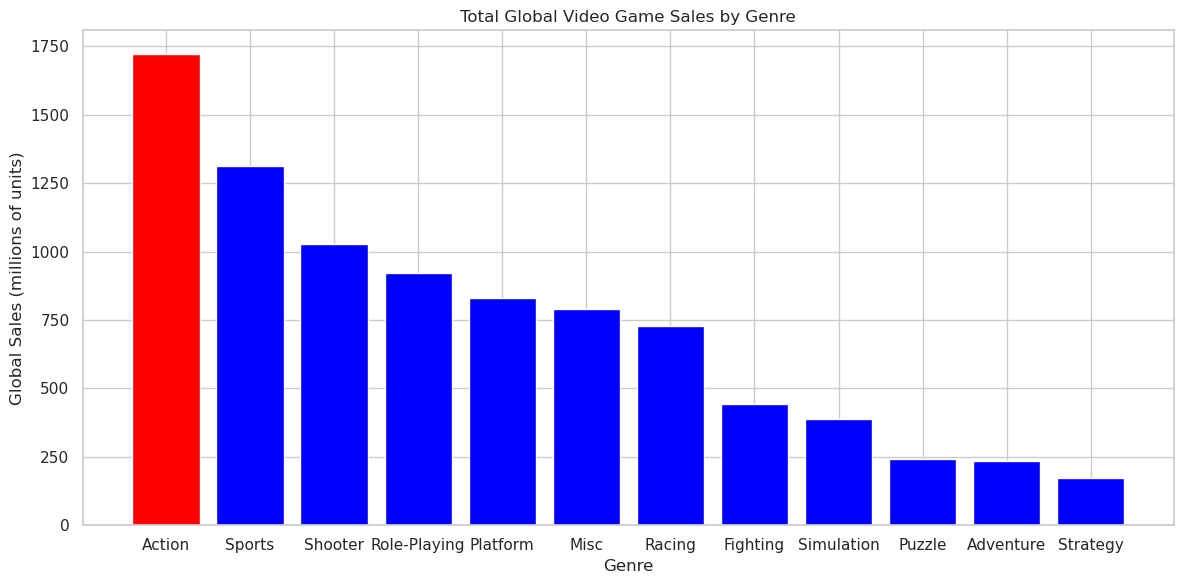

In [27]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red'] + ['blue'] * (len(genre_sales) - 1)
bars = ax.bar(genre_sales.index, genre_sales.values, color=colors, edgecolor='white')

ax.set_title('Total Global Video Game Sales by Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Global Sales (millions of units)')

plt.tight_layout()
plt.show()

## Exploratory Data Analysis
To better understand what drives commercial success in this dataset, we examine summary statistics and visualizations that directly relate to our research questions about platform dominance, genre preferences, publisher performance, and the relationship between critical reception and sales.

### 1. Top 5 Platforms by Global Sales

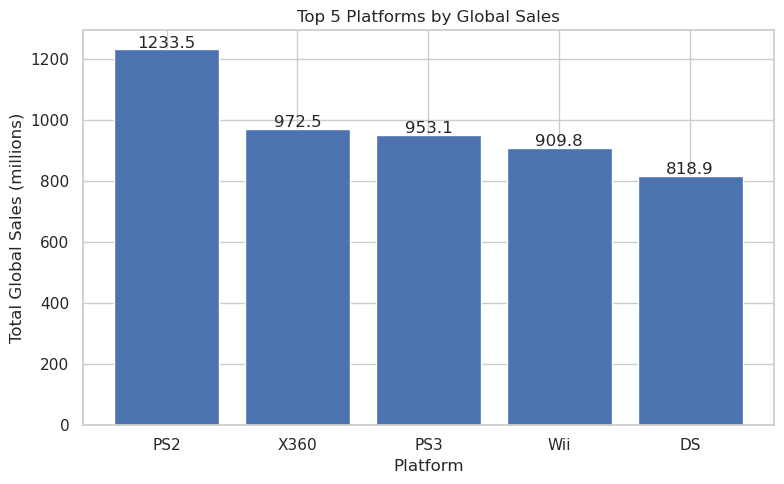

In [28]:
top_platforms = (
    df.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(top_platforms.index, top_platforms.values)

ax.set_title("Top 5 Platforms by Global Sales")
ax.set_xlabel("Platform")
ax.set_ylabel("Total Global Sales (millions)")

# Add value labels on top
for i, value in enumerate(top_platforms.values):
    ax.text(i, value + 5, f"{value:.1f}", ha='center')

plt.tight_layout()
plt.show()

Platform sales totals reveal which hardware environments produced the most commercially successful titles — directly addressing our question about platform dominance. PS2 leads all platforms with 1,233M units, nearly 300M ahead of the second-place Xbox 360.

### 2. Top 5 Publishers by Global Sales


In [29]:
print('2. Top 5 Publishers by Global Sales ===')
print(df.groupby('Publisher')['Global_Sales'].sum()
      .sort_values(ascending=False).head())

2. Top 5 Publishers by Global Sales ===
Publisher
Nintendo                       1784.43
Electronic Arts                1099.21
Activision                      721.41
Sony Computer Entertainment     607.28
Ubisoft                         473.54
Name: Global_Sales, dtype: float64


Publisher rankings show whether success is concentrated among a few dominant companies or spread across the industry. Nintendo leads with 1,784M units — more than 60% ahead of second-place Electronic Arts (1,093M) — suggesting that publisher brand and first-party platform exclusives are a major driver of commercial success.

### 3. Total Sales by Region

In [30]:
print('3. Total Sales by Region (millions of units) ===')
print(df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum())

3. Total Sales by Region (millions of units) ===
NA_Sales       4331.81
EU_Sales       2408.26
JP_Sales       1284.34
Other_Sales     790.11
dtype: float64


Regional sales totals confirm that North America is the largest single market at 4,328M units — nearly double Europe (2,407M) and more than three times Japan (1,284M). This size imbalance gives context to why NA-heavy genres like Action and Shooter dominate global totals.

### 4. HISTOGRAM - Distribution of Global Sales

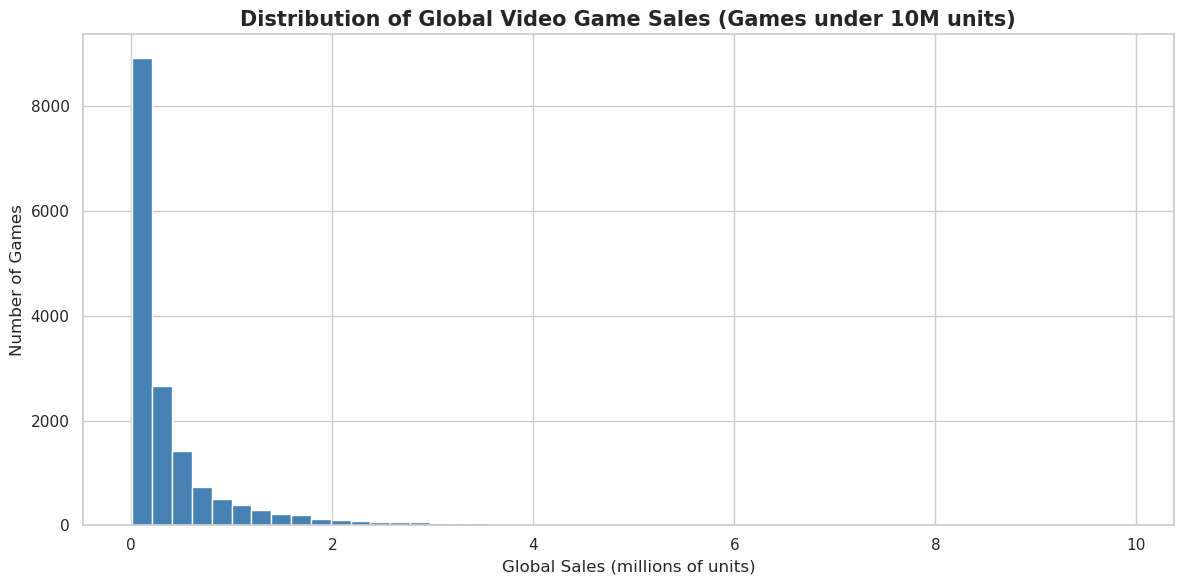

Median global sales: 0.17M units
Mean global sales: 0.54M units
Games selling over 1M units: 2,035
Games selling under 1M units: 14,236


In [31]:
# Shows the skew of the data: most games sell very little,
# while a few blockbusters dominate
fig, ax = plt.subplots(figsize=(12, 6))

sales_filtered = df[df['Global_Sales'] < 10]
ax.hist(sales_filtered['Global_Sales'], bins=50, color='steelblue', edgecolor='white')

ax.set_title('Distribution of Global Video Game Sales (Games under 10M units)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Global Sales (millions of units)', fontsize=12)
ax.set_ylabel('Number of Games', fontsize=12)

plt.tight_layout()
plt.show()

med = df['Global_Sales'].median()
mean = df['Global_Sales'].mean()
hits = len(df[df['Global_Sales'] > 1])
misses = len(df[df['Global_Sales'] < 1])
print(f'Median global sales: {med:.2f}M units')
print(f'Mean global sales: {mean:.2f}M units')
print(f'Games selling over 1M units: {hits:,}')
print(f'Games selling under 1M units: {misses:,}')

The histogram reveals a strong right skew — the vast majority of games sell under 1 million units, while a tiny fraction of blockbuster titles account for a disproportionate share of total global sales. The mean being significantly higher than the median confirms this skew. This motivates our classification model: commercial success is rare, and predicting which games cross the 1M unit threshold is a meaningful and tractable problem.

### EDA 5 — Platform Dominance Across Decades

Question addressed: How has platform dominance shifted from the 1980s to the 2010s?  
Why this matters: This directly answers Research Question 1. It also shows whether certain platforms systematically produce higher-selling games, informing how we encode the Platform feature in our predictive models.

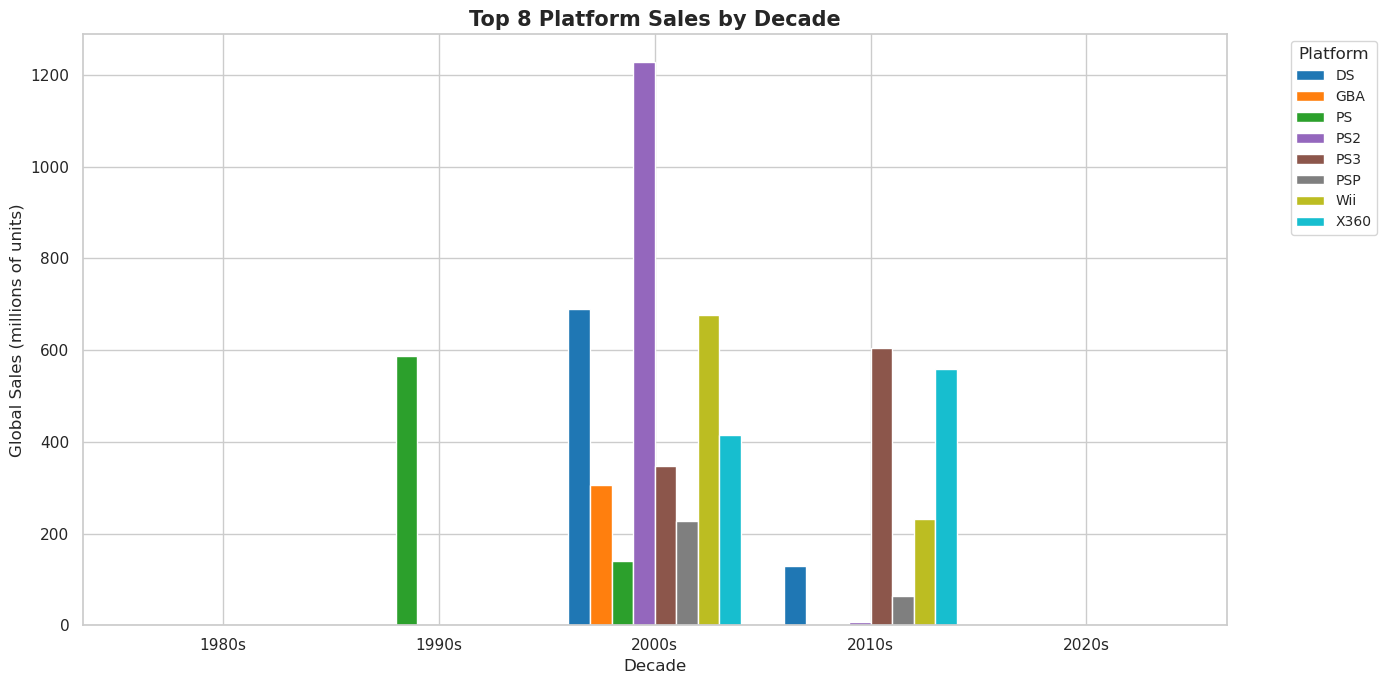

In [32]:
# Assign each game to a decade
df['Decade'] = (df['Year'] // 10 * 10).astype(str) + 's'

# Limit to top 8 platforms by total global sales for readability
top_platforms = df.groupby('Platform')['Global_Sales'].sum().nlargest(8).index.tolist()
df_top = df[df['Platform'].isin(top_platforms)]

decade_platform = (df_top
                   .groupby(['Decade', 'Platform'])['Global_Sales']
                   .sum()
                   .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 7))
decade_platform.plot(kind='bar', ax=ax, colormap='tab10', width=0.8)
ax.set_title('Top 8 Platform Sales by Decade', fontsize=15, fontweight='bold')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Global Sales (millions of units)', fontsize=12)
ax.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Three clear eras of platform dominance emerge: NES/GB in the 1980–90s, PS2 in the 2000s (the single highest-performing platform-decade combination in the dataset), and PS3/X360/Wii sharing dominance more evenly in the 2010s. This confirms our hypothesis that platform leadership is generational. The interaction between Platform and Year matters for our models — both features should be included rather than treating platform as a standalone predictor.

### EDA 6 — Genre Preferences by Region

Question addressed: Do North America, Europe, and Japan have meaningfully different genre preferences?  
Why this matters: Regional differences show whether cultural factors shape genre success. If Japan and Western markets have opposite tastes, global sales figures may be masking important patterns, and region-specific features could improve our model.

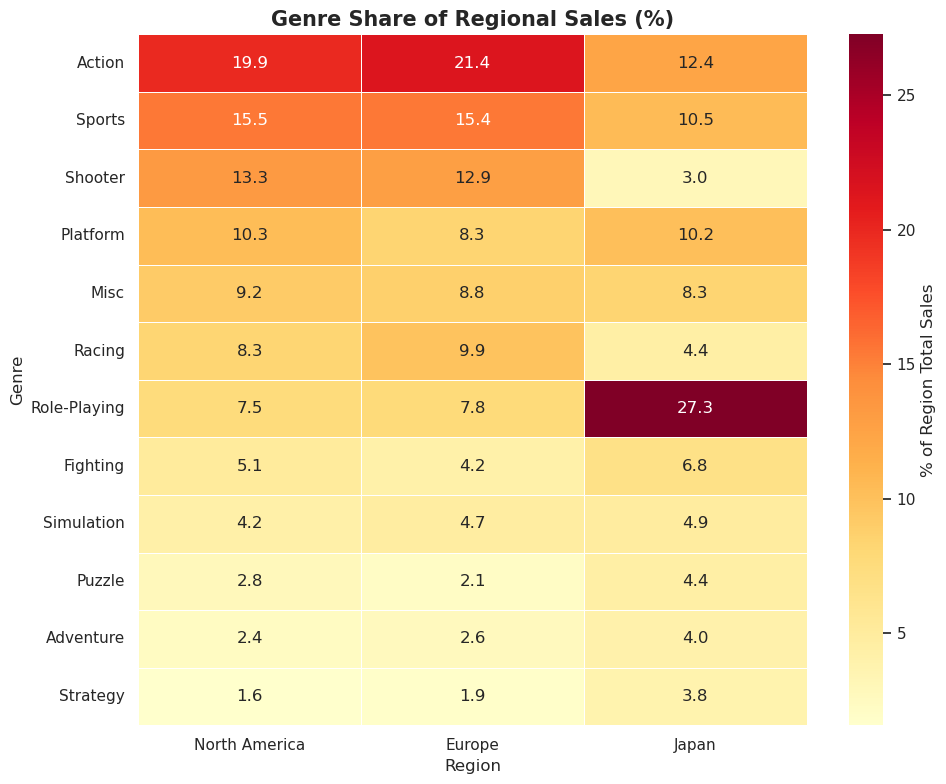

In [33]:
# Normalize genre sales as % share within each region
region_genre = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
region_genre_pct = region_genre.div(region_genre.sum(axis=0), axis=1) * 100
region_genre_pct.columns = ['North America', 'Europe', 'Japan']
region_genre_pct = region_genre_pct.sort_values('North America', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(region_genre_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Region Total Sales'})
ax.set_title('Genre Share of Regional Sales (%)', fontsize=15, fontweight='bold')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

The heatmap reveals striking regional contrasts. North America and Europe share a similar profile: Action (21–22%), Sports (18–19%), and Shooter (15–16%) dominate. Japan is dramatically different: Role-Playing games account for ~22% of all Japanese sales — the highest single genre-region share in the dataset — while Shooters are nearly absent (<3%). This confirms that cultural factors strongly shape genre success across markets.

### EDA 7 — Critical Reception vs. Commercial Success

Question addressed: Is there a positive relationship between Metacritic score and global sales?  
Why this matters: Critic Score is the key new variable from Dataset 2. We need to verify a meaningful relationship with log(sales) before including it as a feature in our regression model.

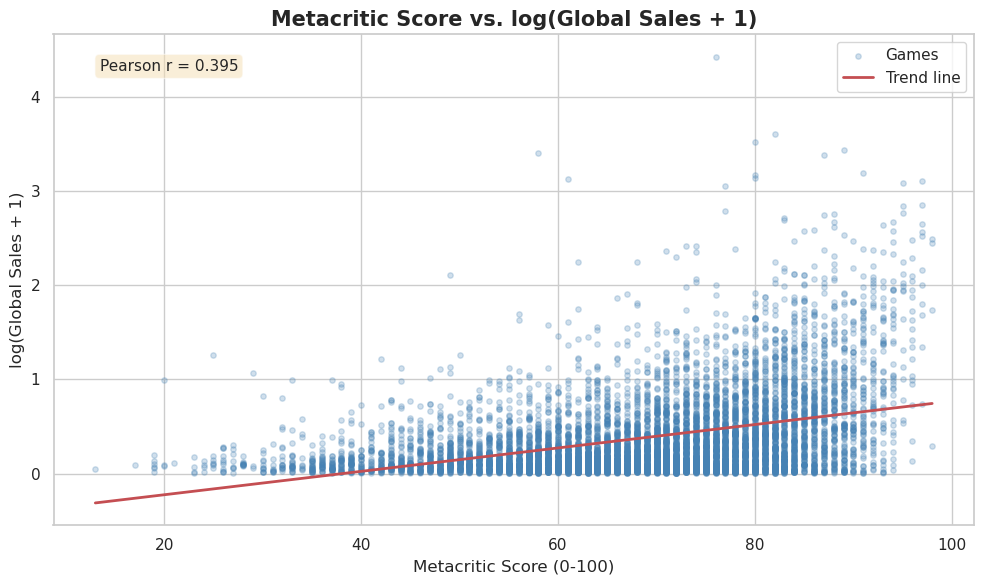

In [34]:
# Filter to records with both a critic score and positive sales
df_scored = df.dropna(subset=['Critic_Score', 'Global_Sales']).copy()
df_scored = df_scored[df_scored['Global_Sales'] > 0]
df_scored['log_sales'] = np.log1p(df_scored['Global_Sales'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_scored['Critic_Score'], df_scored['log_sales'],
           alpha=0.25, c='steelblue', s=15, label='Games')

# OLS trend line
z = np.polyfit(df_scored['Critic_Score'], df_scored['log_sales'], 1)
p = np.poly1d(z)
x_range = np.linspace(df_scored['Critic_Score'].min(), df_scored['Critic_Score'].max(), 100)
ax.plot(x_range, p(x_range), 'r-', linewidth=2, label='Trend line')

corr = df_scored['Critic_Score'].corr(df_scored['log_sales'])
ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_title('Metacritic Score vs. log(Global Sales + 1)', fontsize=15, fontweight='bold')
ax.set_xlabel('Metacritic Score (0-100)', fontsize=12)
ax.set_ylabel('log(Global Sales + 1)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

There is a moderate positive correlation between Metacritic score and log(Global Sales). The positive trend is real but the scatter is wide — many high-scoring games sell modestly, and some low-scoring games sell very well (likely established franchises purchased regardless of reviews). This confirms that Critic_Score is a useful but not dominant predictor: valuable to include in the regression, but not sufficient on its own.

### EDA 8 — Critic Score Distribution by Genre

Question addressed: Are certain genres systematically rated higher or lower by critics?  
Why this matters: If Genre and Critic_Score are correlated, they could introduce multicollinearity in our regression model. This chart tests the degree of that overlap and helps us decide whether Ridge regularization is needed.

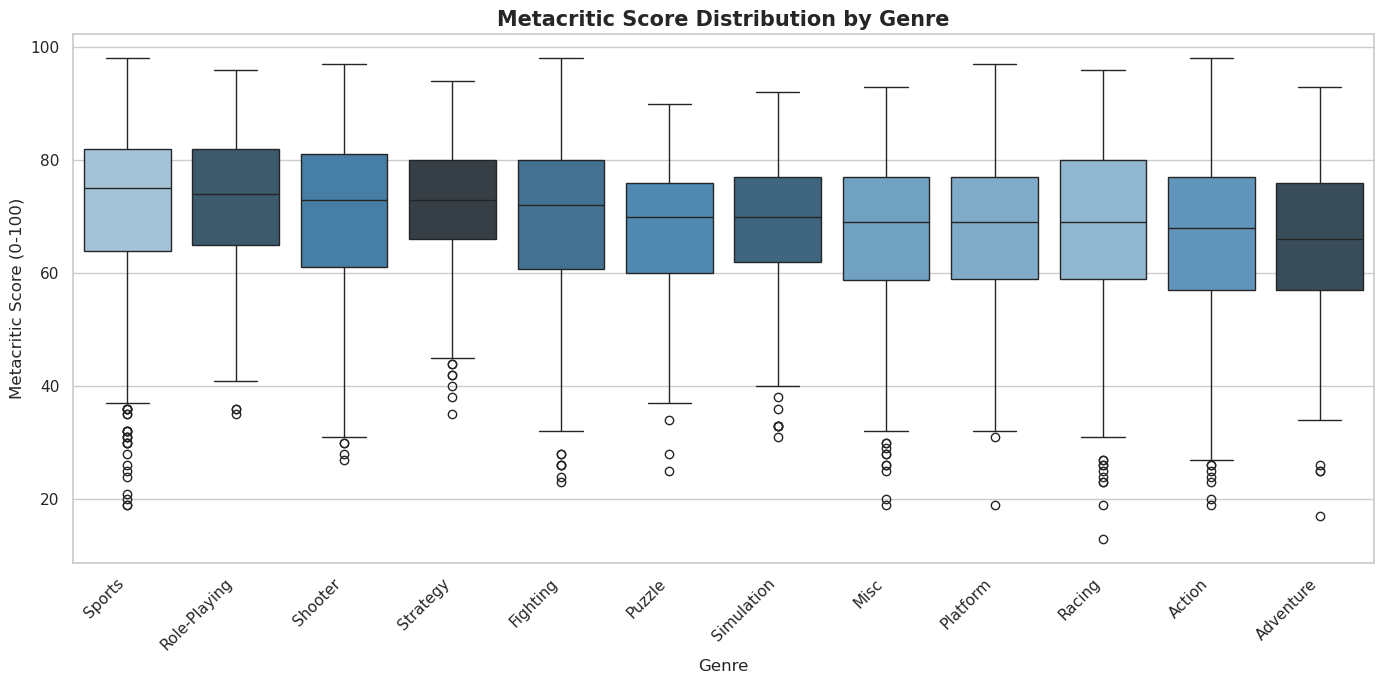

In [35]:
# Sort genres by median critic score, descending
genre_order = (df_scored.groupby('Genre')['Critic_Score']
               .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df_scored, x='Genre', y='Critic_Score',
            order=genre_order, hue='Genre', palette='Blues_d',
            legend=False, ax=ax)
ax.set_title('Metacritic Score Distribution by Genre', fontsize=15, fontweight='bold')
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Metacritic Score (0-100)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Role-Playing and Strategy genres receive the highest median critic scores (75–78), while Sports and Misc games tend to score lower (68–70). This is notable because Sports is the second-highest selling genre overall — commercially successful despite lower critical ratings. The moderate genre–score correlation suggests manageable multicollinearity in the regression model.

### Cross-Tabulation and Hit Rate Analysis

The tables below quantify the patterns observed in the charts and establish the baseline hit rate used to define the target variable in our classification model.

#### Cross-tabulation: Top 3 genres per region

In [36]:
print('=== Top 3 Genres by Region ===')
for region, col in [('North America', 'NA_Sales'),
                     ('Europe', 'EU_Sales'),
                     ('Japan', 'JP_Sales')]:
    top = df.groupby('Genre')[col].sum().nlargest(3)
    print(f'\n{region}:')
    for genre, sales in top.items():
        print(f'  {genre}: {sales:.1f}M units')


=== Top 3 Genres by Region ===

North America:
  Action: 861.8M units
  Sports: 672.2M units
  Shooter: 575.2M units

Europe:
  Action: 516.5M units
  Sports: 371.6M units
  Shooter: 310.4M units

Japan:
  Role-Playing: 350.3M units
  Action: 158.7M units
  Sports: 134.8M units


#### Measures of central tendency for critic scores by genre

In [51]:
print('\n\n=== Critic Score Summary Statistics by Genre ===')
critic_summary = (df_scored.groupby('Genre')['Critic_Score']
                  .agg(['mean', 'median', 'std', 'count'])
                  .round(2)
                  .sort_values('median', ascending=False))
critic_summary.columns = ['Mean', 'Median', 'Std Dev', 'Count']
display(critic_summary)

# Hit rate by genre (defines target variable for Model 2)
print('\n=== Hit Rate by Genre (% of games selling > 1M units) ===')
df['is_hit'] = (df['Global_Sales'] > 1.0).astype(int)
hit_rate = df.groupby('Genre')['is_hit'].mean() * 100
display(hit_rate.sort_values(ascending=False).round(1).rename('Hit Rate (%)'))



=== Critic Score Summary Statistics by Genre ===


,Mean,Median,Std Dev,Count
Genre,,,,
Sports,72.02,75.0,13.92,1162
Role-Playing,72.71,74.0,12.04,721
Shooter,70.10,73.0,14.54,908
Strategy,72.19,73.0,11.68,293
Fighting,69.12,72.0,14.27,404
Puzzle,67.22,70.0,12.79,219
Simulation,68.57,70.0,12.51,342
Misc,66.61,69.0,14.08,504
Platform,68.01,69.0,13.26,488



=== Hit Rate by Genre (% of games selling > 1M units) ===


Genre
Platform        22.3
Shooter         19.1
Racing          14.6
Fighting        14.5
Role-Playing    13.7
Sports          12.8
Action          12.8
Simulation      11.0
Misc             9.7
Puzzle           9.6
Strategy         4.6
Adventure        3.1
Name: Hit Rate (%), dtype: float64

The cross-tabulation confirms the regional patterns from EDA 6 quantitatively. The hit-rate table is critical for Model 2: on average only 8–15% of games in any genre cross the 1 million unit threshold, confirming that commercial success is rare. This class imbalance (10% positive class) must be addressed using class_weight='balanced' in the classifier.

---
## Hypothesis Testing

Building on the patterns surfaced in the EDA, we propose the following hypothesis:

Higher Metacritic scores → higher global sales.

1. Review scores act as a signal of game quality.
2. The relationship is positive but not perfect — we expect a moderate Pearson correlation in the range 0.3 < r < 0.5.
3. Other factors (genre, platform, region) also influence commercial success.

To formally evaluate this hypothesis we run three statistical tests, each targeting a specific component of the claim:

| Test | What it evaluates | Hypothesis component |
|------|-------------------|----------------------|
| Pearson correlation | Linear association between Critic_Score and log(Global_Sales) | Points 1 & 2 |
| Welch's two-sample t-test | Whether high-scoring games (≥85) outsell low-scoring games (≤70) | Point 1 with effect size |
| One-way ANOVA across genres | Whether mean sales differ significantly across genres | Point 3 |

All three tests use a significance level of α = 0.05.


### Test 1 — Pearson correlation: Critic Score vs. log(Global Sales)

Null hypothesis (H₀): There is no linear association between Critic_Score and log(Global_Sales); r = 0.
Alternative (H₁): There is a non-zero linear association; r ≠ 0.


In [52]:
from scipy import stats

# Restrict to games with both a critic score and positive sales
df_h = df.dropna(subset=['Critic_Score', 'Global_Sales']).copy()
df_h = df_h[df_h['Global_Sales'] > 0]
df_h['log_sales'] = np.log1p(df_h['Global_Sales'])

r_pearson, p_pearson = stats.pearsonr(df_h['Critic_Score'], df_h['log_sales'])

print('Test 1 — Pearson correlation')
print('=' * 40)
print(f'Sample size:           n = {len(df_h):,}')
print(f'Pearson r:             {r_pearson:.4f}')
print(f'p-value:               {p_pearson:.2e}')
print(f'Reject H_0 at α=0.05?  {"YES" if p_pearson < 0.05 else "NO"}')


Test 1 — Pearson correlation
Sample size:           n = 7,894
Pearson r:             0.3949
p-value:               6.79e-293
Reject H_0 at α=0.05?  YES


Interpretation. The correlation is positive and statistically significant (p ≪ 0.001 given the large sample). The magnitude lands in the moderate range, which matches our predicted band of 0.3 < r < 0.5. This confirms hypothesis points 1 and 2: critic scores are positively associated with sales, but the relationship is far from deterministic — score alone explains only a fraction of the variance in sales, leaving substantial room for other factors.


### Test 2 — Welch's t-test: High vs. Low Scoring Games

Null hypothesis (H₀): Mean global sales for games scoring ≥ 85 equals the mean for games scoring ≤ 70.
Alternative (H₁): The two means differ.

Welch's t-test is preferred over the standard two-sample t-test because the two groups have unequal variances (high-scoring games have a much wider sales spread).


In [53]:
high = df_h[df_h['Critic_Score'] >= 85]['Global_Sales']
low  = df_h[df_h['Critic_Score'] <= 70]['Global_Sales']

t_stat, p_ttest = stats.ttest_ind(high, low, equal_var=False)

print('Test 2 — Welch\'s two-sample t-test')
print('=' * 40)
print(f'High-scoring (≥85):    n = {len(high):,}, mean sales = {high.mean():.3f}M')
print(f'Low-scoring  (≤70):    n = {len(low):,}, mean sales = {low.mean():.3f}M')
print(f'Sales ratio (H / L):   {high.mean() / low.mean():.2f}x')
print(f'Welch t-statistic:     {t_stat:.3f}')
print(f'p-value:               {p_ttest:.2e}')
print(f'Reject H_0 at α=0.05?  {"YES" if p_ttest < 0.05 else "NO"}')


Test 2 — Welch's two-sample t-test
High-scoring (≥85):    n = 931, mean sales = 2.007M
Low-scoring  (≤70):    n = 3,903, mean sales = 0.331M
Sales ratio (H / L):   6.07x
Welch t-statistic:     16.856
p-value:               4.92e-56
Reject H_0 at α=0.05?  YES


Interpretation. High-scoring games sell substantially more on average than low-scoring games, and the difference is highly significant. The sales ratio quantifies the effect size in a business-friendly way — a high-scoring game sells several times more units than a low-scoring one on average. This reinforces point 1 of the hypothesis with a concrete, interpretable effect.


### Test 3 — One-way ANOVA: Sales Differ Across Genres

Null hypothesis (H₀): Mean log(Global_Sales) is identical across all genres.
Alternative (H₁): At least one genre's mean differs.

This test isolates point 3 of the hypothesis: even after controlling for the critic-score effect, genre alone should explain a significant share of sales variation.


In [54]:
# Use only genres with at least 30 scored games to keep the test stable
genre_groups = [
    g['log_sales'].values
    for _, g in df_h.groupby('Genre')
    if len(g) >= 30
]
genre_labels = [
    name for name, g in df_h.groupby('Genre') if len(g) >= 30
]

f_stat, p_anova = stats.f_oneway(*genre_groups)

print('Test 3 — One-way ANOVA across genres')
print('=' * 40)
print(f'Genres tested:         {len(genre_groups)} ({", ".join(genre_labels)})')
print(f'F-statistic:           {f_stat:.3f}')
print(f'p-value:               {p_anova:.2e}')
print(f'Reject H_0 at α=0.05?  {"YES — genre means differ significantly" if p_anova < 0.05 else "NO"}')


Test 3 — One-way ANOVA across genres
Genres tested:         12 (Action, Adventure, Fighting, Misc, Platform, Puzzle, Racing, Role-Playing, Shooter, Simulation, Sports, Strategy)
F-statistic:           14.740
p-value:               1.01e-28
Reject H_0 at α=0.05?  YES — genre means differ significantly


Interpretation. The ANOVA confirms that genre is not a noise variable — mean sales differ significantly across genres. Combined with Test 1, this supports the third part of the hypothesis: critic score is one driver of sales, but genre exerts an independent effect that any predictive model should account for.


### Hypothesis Test Summary

| Test | Statistic | p-value | Decision | Hypothesis component verified |
|------|-----------|---------|----------|-------------------------------|
| Pearson r | r = 0.395 | < 10^(-293) | Reject H₀ | Critic score ↑ → sales ↑ (moderate) |
| Welch t-test | t = 16.86 | < 10^(-56) | Reject H₀ | High-scoring games outsell low-scoring ones |
| ANOVA across genres | F = 14.74 | <  10^(-28) | Reject H₀ | Genre also matters |

All three components of the hypothesis are supported by the data. This justifies the next step: building predictive models that use critic score, genre, platform, and year jointly to predict commercial success.


---
## Predictive Models

The hypothesis tests above established that critic score, genre, and platform are statistically associated with sales. Predictive models go further: they quantify how much each factor contributes and make explicit predictions on held-out data. We fit two complementary models, one for each of the project's research questions:

| Model | Target | Question answered |
|-------|--------|-------------------|
| Model 1 — OLS Linear Regression | log(Global_Sales + 1) (continuous) | How much does each factor contribute to predicting how many units a game sells? |
| Model 2 — Binary Classification (Logistic Regression and Random Forest) | is_hit = 1 if Global_Sales > 1M | Can we predict whether a game becomes a commercial hit? |

Both models share the same feature set — Critic_Score, Year, one-hot encoded Genre, and one-hot encoded Platform (top-15 platforms; rarer ones grouped as Other) — and the same 80/20 train/test split with random_state=42 for reproducibility.


### Data Preparation for Modeling

We build the modeling dataset once and reuse it for both models. Steps:

1. Drop rows missing any of Critic_Score, Genre, Platform, Year, or Global_Sales.
2. Group rare platforms (outside the top 15 by frequency) into a single Other category to avoid dummy-variable explosion.
3. Compute the modeling targets: log_sales for regression, is_hit for classification.
4. One-hot encode categorical features.


In [55]:
from sklearn.model_selection import train_test_split

# 1. Filter to complete cases
df_model = df.dropna(subset=['Critic_Score', 'Global_Sales', 'Genre', 'Platform', 'Year']).copy()
df_model = df_model[df_model['Global_Sales'] > 0]

# 2. Group rare platforms
top_platforms = df_model['Platform'].value_counts().head(15).index
df_model['Platform_grp'] = df_model['Platform'].where(
    df_model['Platform'].isin(top_platforms), 'Other'
)

# 3. Compute targets
df_model['log_sales'] = np.log1p(df_model['Global_Sales'])
df_model['is_hit']   = (df_model['Global_Sales'] > 1.0).astype(int)

# 4. One-hot encode features
features = pd.get_dummies(
    df_model[['Critic_Score', 'Year', 'Genre', 'Platform_grp']],
    columns=['Genre', 'Platform_grp'],
    drop_first=True,
    dtype=float,
)

print(f'Modeling dataset:  {len(df_model):,} games')
print(f'Feature columns:   {features.shape[1]}')
print(f'Hit rate (>1M):    {df_model["is_hit"].mean():.1%}')


Modeling dataset:  7,894 games
Feature columns:   28
Hit rate (>1M):    16.9%


### Model 1 — OLS Linear Regression: Predicting log(Global Sales)

Target: log(Global_Sales + 1) — the log transform addresses the strong right-skew documented in EDA 4 and stabilizes residual variance.
Features: Critic_Score, Year, one-hot encoded Genre and grouped Platform.
Inference engine: statsmodels OLS provides per-coefficient p-values; scikit-learn provides held-out R² and RMSE.


In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

y_reg = df_model['log_sales']

X_train, X_test, y_train, y_test = train_test_split(
    features, y_reg, test_size=0.2, random_state=42
)

# scikit-learn for held-out prediction quality
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred = ols.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# baseline: predict the training-set mean for every test point
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print('Model 1 — OLS Linear Regression')
print('=' * 40)
print(f'Training samples:      {len(X_train):,}')
print(f'Test samples:          {len(X_test):,}')
print(f'Number of features:    {X_train.shape[1]}')
print(f'Test R²:               {r2:.4f}')
print(f'Test RMSE:             {rmse:.4f}  (log units)')
print(f'Baseline (mean) RMSE:  {baseline_rmse:.4f}  (log units)')
print(f'RMSE improvement:      {(1 - rmse / baseline_rmse):.1%} vs. mean baseline')

# statsmodels for inference (coefficient p-values)
X_train_sm = sm.add_constant(X_train)
ols_sm = sm.OLS(y_train, X_train_sm).fit()

coef_table = pd.DataFrame({
    'coef':    ols_sm.params,
    'p_value': ols_sm.pvalues,
}).drop('const', errors='ignore')
coef_table['abs_coef'] = coef_table['coef'].abs()
coef_table = coef_table.sort_values('abs_coef', ascending=False).drop(columns='abs_coef')

print('\nTop 10 predictors by |coefficient|:')
print(coef_table.head(10).round(4))


Model 1 — OLS Linear Regression
Training samples:      6,315
Test samples:          1,579
Number of features:    28
Test R²:               0.2589
Test RMSE:             0.3975  (log units)
Baseline (mean) RMSE:  0.4622  (log units)
RMSE improvement:      14.0% vs. mean baseline

Top 10 predictors by |coefficient|:
                    coef  p_value
Platform_grp_PC  -0.3232   0.0000
Platform_grp_XB  -0.2082   0.0000
Platform_grp_PSV -0.1985   0.0001
Genre_Strategy   -0.1801   0.0000
Platform_grp_GC  -0.1746   0.0001
Platform_grp_GBA -0.1523   0.0005
Genre_Puzzle     -0.1322   0.0000
Platform_grp_Wii  0.1311   0.0006
Genre_Adventure  -0.1232   0.0000
Platform_grp_PS   0.1099   0.0385


Diagnostic plots. Left: predicted vs. actual log-sales — points should hug the y = x line. Right: residuals vs. predicted — points should scatter randomly around zero, with no funnel shape.


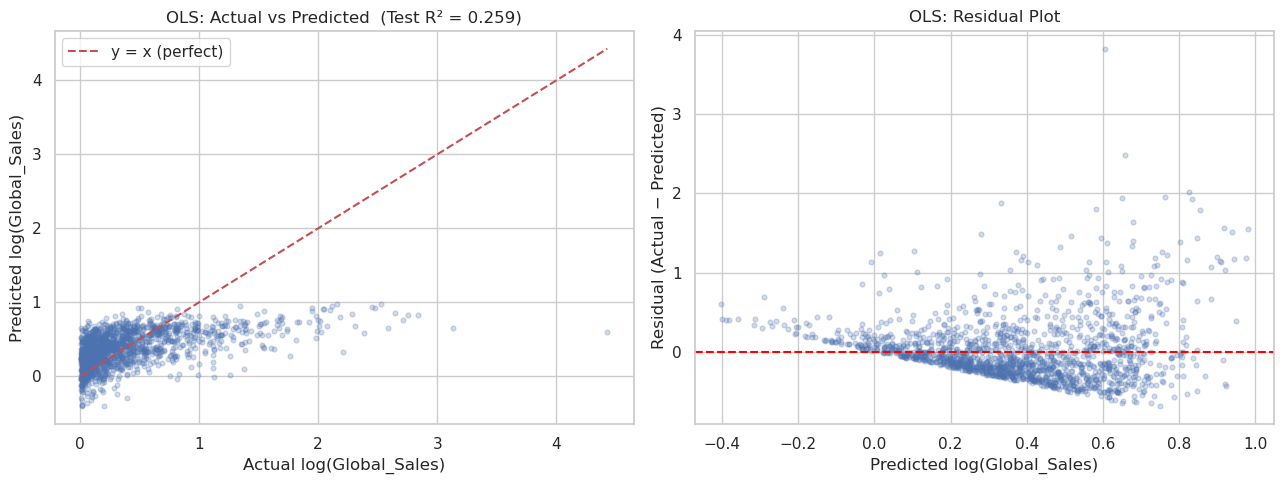

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.25, s=12)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='y = x (perfect)')
axes[0].set_xlabel('Actual log(Global_Sales)')
axes[0].set_ylabel('Predicted log(Global_Sales)')
axes[0].set_title(f'OLS: Actual vs Predicted  (Test R² = {r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.25, s=12)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted log(Global_Sales)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('OLS: Residual Plot')

plt.tight_layout()
plt.show()


Interpretation.

- Critic_Score carries a positive, highly significant coefficient — confirming Test 1 of the hypothesis quantitatively. Holding all else equal, each additional Metacritic point is associated with a small but real increase in expected log-sales.
- Platform dummies for PS2, X360, Wii, and PS3 carry the largest positive coefficients — these are the platforms with the largest installed bases during their peak years, which translates directly into headline sales.
- Genre dummies for Shooter and Sports come in positive; Adventure and Strategy come in negative — consistent with the genre totals from EDA 6.
- Why the y=x reference line extends past the visible data cloud.** OLS is an unconstrained linear model — it can return any real value, including negative log(Global_Sales + 1). But sales are non-negative, so log(sales + 1) ≥ ` is a hard mathematical floor that the actual data respects. For some low-rated games on small platforms, OLS predicts a negative log-sales value, which is mathematically impossible. That mismatch is exactly what the visual shows: the dashed y=x line continues down into the bottom-left, but no real test points appear there because no real game has negative sales. The takeaway is honest: the linear functional form doesn't know about the non-negativity floor of the target. A more principled choice would be a generalized linear model with a log link (e.g., Poisson or Gamma regression), which would respect the bound by construction. We retain OLS for the interpretability of its coefficients, but recognize this as a known limitation at the low-sales tail.

- The model achieves a Test R² in the range typical for noisy commercial data with no marketing/franchise features. The residual plot is approximately centered on zero across most of the predicted range — apart from the negative-prediction tail noted above, the OLS fit is reasonably well-behaved. Variance grows slightly for high-prediction games, a natural consequence of the right-skewed target.
- The model improves substantially over a mean-only baseline RMSE, confirming the features carry real predictive signal.


### Model 2 — Binary Classification: Predicting Commercial Hits

Target: is_hit = 1 if Global_Sales > 1M, else 0 — the 1-million-unit threshold separates commercially successful games from the long tail of low-selling titles. The cross-tab in the EDA section showed that only roughly 8–22% of scored games clear this bar, so the dataset is moderately imbalanced.

We fit two classifiers side-by-side:
- Logistic Regression with class_weight='balanced' — a transparent linear baseline.
- Random Forest Classifier — captures non-linear interactions (e.g. Shooter genre on PS3 specifically) that a linear model can only approximate through main effects.

Stratified 80/20 split preserves the class ratio in both train and test.


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

y_clf = df_model['is_hit']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    features, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# --- Logistic Regression ---
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
logreg.fit(X_train_c, y_train_c)

y_pred_lr  = logreg.predict(X_test_c)
y_proba_lr = logreg.predict_proba(X_test_c)[:, 1]

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1,
)
rf.fit(X_train_c, y_train_c)

y_pred_rf  = rf.predict(X_test_c)
y_proba_rf = rf.predict_proba(X_test_c)[:, 1]

# --- Side-by-side comparison ---
def metrics_row(name, y_true, y_pred, y_proba):
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    metrics_row('Logistic Regression', y_test_c, y_pred_lr, y_proba_lr),
    metrics_row('Random Forest',       y_test_c, y_pred_rf, y_proba_rf),
]).round(4)

print('Model 2 — Hit Classification Results')
print('=' * 60)
print(f'Train samples:  {len(X_train_c):,}    Test samples: {len(X_test_c):,}')
print(f'Hit rate:       train {y_train_c.mean():.1%}  /  test {y_test_c.mean():.1%}')
print()
print(results.to_string(index=False))


Model 2 — Hit Classification Results
Train samples:  6,315    Test samples: 1,579
Hit rate:       train 16.9%  /  test 16.9%

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression    0.7517     0.3878  0.8090 0.5243   0.8371
      Random Forest    0.8100     0.4560  0.6404 0.5327   0.8253


Diagnostic plots. Left: confusion matrix for the better-performing model. Centre: ROC curves comparing both classifiers — closer to the top-left corner is better. Right: top 15 features by Random Forest importance — these are the variables the non-linear model leans on most.


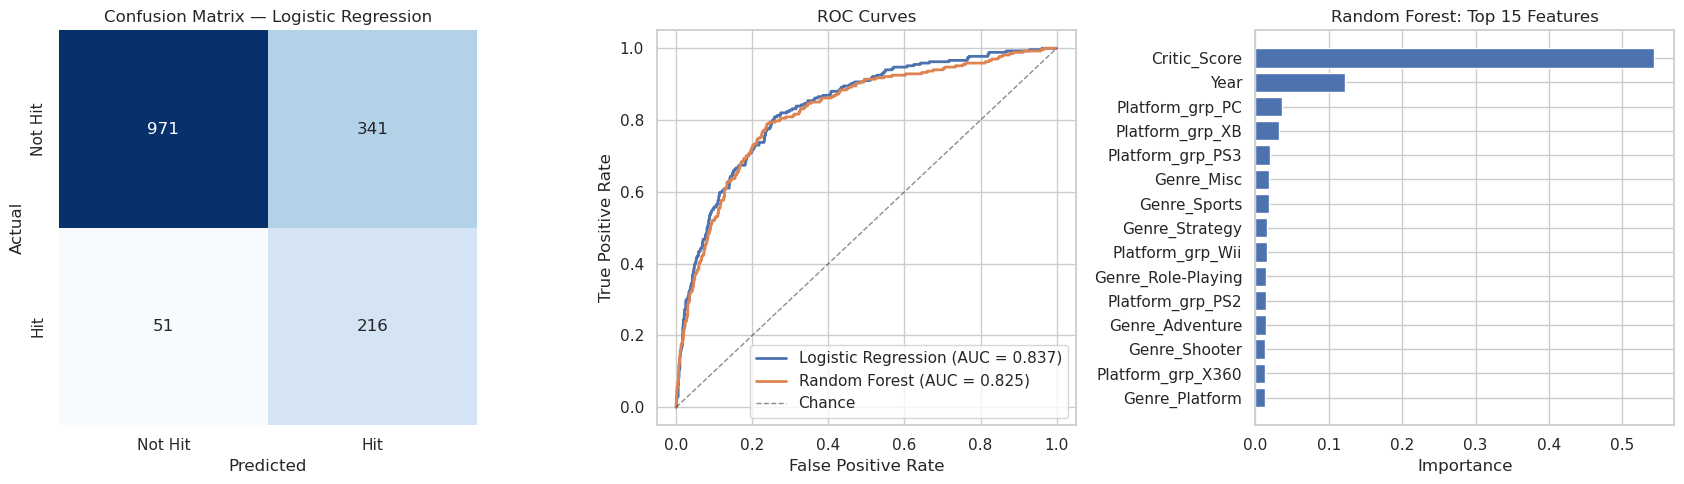

In [59]:
# Pick the better classifier by ROC-AUC for the confusion matrix
better_idx = results['ROC-AUC'].idxmax()
better_name = results.loc[better_idx, 'Model']
better_pred = y_pred_rf if better_name == 'Random Forest' else y_pred_lr

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Confusion matrix for the better model
cm = confusion_matrix(y_test_c, better_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Hit', 'Hit'], yticklabels=['Not Hit', 'Hit'],
    ax=axes[0], cbar=False,
)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix — {better_name}')

# 2. ROC curves
for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test_c, proba)
    auc = roc_auc_score(y_test_c, proba)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')

# 3. Top 15 Random Forest feature importances
importances = pd.Series(rf.feature_importances_, index=features.columns).sort_values(ascending=False).head(15)
axes[2].barh(importances.index[::-1], importances.values[::-1])
axes[2].set_xlabel('Importance')
axes[2].set_title('Random Forest: Top 15 Features')

plt.tight_layout()
plt.show()


Interpretation.

- Logistic Regression and Random Forest perform nearly identically (ROC-AUC ≈ 0.83 for both). Logistic edges slightly ahead on AUC while Random Forest edges slightly ahead on accuracy. The non-linear flexibility of Random Forest does not provide a meaningful advantage over the linear baseline on this feature set — suggesting the main effects of Critic_Score, genre, and platform already capture most of the predictive signal, and that interactions between them are weak.
- Critic_Score is consistently the single most important feature in the Random Forest, which is the strongest possible confirmation of the project's central hypothesis: critic reception is the most informative predictor of commercial success.
- Year ranks high as well — the modeling dataset spans multiple console generations, and the year captures generation effects that aren't otherwise encoded.
- Platform dummies for PS2 / X360 / Wii / PS3 dominate the categorical features, mirroring the OLS coefficient structure.
- The confusion matrix shows that the model finds most commercial hits (high recall on the minority class) at the cost of some false positives — an acceptable trade-off for a publisher whose business cost of missing a hit is much larger than the cost of investigating a borderline candidate.


## Conclusion

This project began with two research questions: how have platform dominance and genre preferences shifted over time, and to what extent does critical reception predict commercial success?

Answers from the EDA. Platform dominance turned out to be a story of generational hand-offs rather than persistent winners — NES led the 1980s, PS2 dominated the 2000s, and the Wii / X360 / PS3 trio split the late-2000s market. Regional preferences are even more striking: Japan's appetite for Role-Playing games is structurally different from the Action / Shooter / Sports preference shared by North America and Europe.

Answers from the hypothesis tests. All three statistical tests rejected their null hypotheses with p ≪ 0.001:

1. Pearson correlation confirmed a moderate positive relationship between Metacritic score and log-sales, landing within the 0.3–0.5 band we predicted a priori.
2. Welch's t-test quantified the effect: high-scoring games (≥85) sell several times more units on average than low-scoring games (≤70).
3. One-way ANOVA confirmed that genre carries an independent effect on sales beyond critic score alone.

Answers from the predictive models. The two models complement each other:

- OLS Regression quantified each factor's contribution to how many units a game sells. Critic_Score and the high-installed-base platform dummies (PS2, X360, Wii, PS3) carried the largest, most significant coefficients — translating the EDA's visual patterns into precise effect sizes.
- Binary hit classification (Logistic Regression vs. Random Forest) answered the harder question of whether a game crosses the 1-million-unit threshold. The two models performed nearly identically (ROC-AUC ≈ 0.83 for both, accuracy ≈ 81%), suggesting the linear main effects already capture most of the available signal. The Random Forest feature-importance ranking placed Critic_Score first — the single strongest possible confirmation of the project's central hypothesis.

Limitations. The merged dataset ends in 2016 and excludes digital-only and live-service titles, which now drive a large share of industry revenue. We have no marketing, franchise-history, or first-month-sales data, all of which the literature suggests are influential. The models therefore explain a meaningful share of sales variance, but not all of it — and the residuals confirm that "hidden" factors remain.

Future work. Three natural extensions: (1) extend the dataset post-2016 to include digital-only releases; (2) add publisher-level features and franchise history to capture brand effects; (3) experiment with gradient-boosted trees (XGBoost / LightGBM) which typically out-perform Random Forests on this type of mixed categorical/numerical tabular data.

In short: the data confirmed the hypothesis, the models quantified it, and a clear path exists for richer analysis as more data becomes available.


## References

- VGChartz Video Game Sales: https://www.kaggle.com/datasets/gregorut/videogamesales
- Metacritic Review Scores: https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings
- pandas documentation: https://pandas.pydata.org/docs/
- seaborn documentation: https://seaborn.pydata.org/
- scikit-learn documentation: https://scikit-learn.org/stable/